# EDA - Investigação de Churn

*~ por: Gabriel Bruno, Gabrieli Morales, Matheus Ferreira*

Analisar por que clientes deixam de comprar, cancelar um serviço ou encerram seu relacionamento com uma empresa.

## Preparando o projeto

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/Gbrunoo7/GC_IA_Dados_2026/refs/heads/main/aula08_desafio_Explorative_Data_Analysis/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Analisando os Dados

In [22]:
# 1. Carregar os dados (mantendo os nomes originais das colunas)
df_original_cols = pd.read_csv("https://raw.githubusercontent.com/Gbrunoo7/GC_IA_Dados_2026/refs/heads/main/aula08_desafio_Explorative_Data_Analysis/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Converter a coluna 'TotalCharges' para numérico e tratar valores ausentes
df_original_cols['TotalCharges'] = pd.to_numeric(df_original_cols['TotalCharges'], errors='coerce')
df_original_cols.dropna(subset=['TotalCharges'], inplace=True)

# 3. Filtrar o DataFrame para 'Churn' == 'Yes'
df_churn_original_cols = df_original_cols.query("Churn == 'Yes'")

In [23]:
df_churn = df[df["Churn"] == "Yes"].copy()
df_churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,1869.000000,1869.000000,1869.000000
mean,0.254682,17.979133,74.441332
std,0.435799,19.531123,24.666053
min,0.000000,1.000000,18.850000
25%,0.000000,2.000000,56.150000
50%,0.000000,10.000000,79.650000
75%,1.000000,29.000000,94.200000
max,1.000000,72.000000,118.350000


In [24]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [25]:
df.shape

(7043, 21)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Analisando a qualidade dos Dados

Possibilidade de valores ausentes

In [27]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Possibilidade de registros duplicados

In [28]:
df.duplicated().sum()

np.int64(0)

Possibilidade de IDs repetidos

In [29]:
df["customerID"].duplicated().sum()

np.int64(0)

Tudo ok, podemos continuar 👍

## Entender tamanho do Churn

Número de cancelamentos

In [30]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


Taxa de cancelamento

In [31]:
taxa_churn = (df["Churn"] == "Yes").mean() * 100

print(f"Taxa de churn: {taxa_churn:.2f}%")

Taxa de churn: 26.54%


## Hipóteses e Insights

Insight — O que os dados revelam?

Hipótese — Por que isso pode estar acontecendo?

---

| N | Perguntas |
| --- | --- |
| 1 | Clientes que contratam planos com mensalidades mais altas tendem a cancelar mais cedo?|
| 2 | Quem é a pessoa média que cancela? |
| 3 |Quais serviços mais cancelados? |

---

### Insight e Hipótese 1

#### Clientes que contratam planos com mensalidades mais altas tendem a cancelar mais cedo?

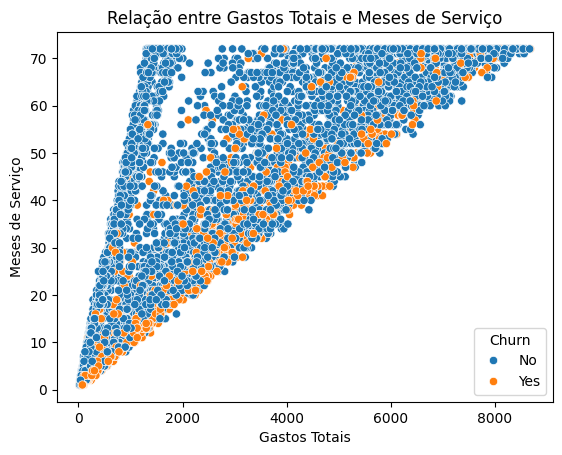

In [32]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

sns.scatterplot(x='TotalCharges', y='tenure', hue='Churn', data=df)
plt.title('Relação entre Gastos Totais e Meses de Serviço')
plt.xlabel('Gastos Totais')
plt.ylabel('Meses de Serviço')
plt.show()

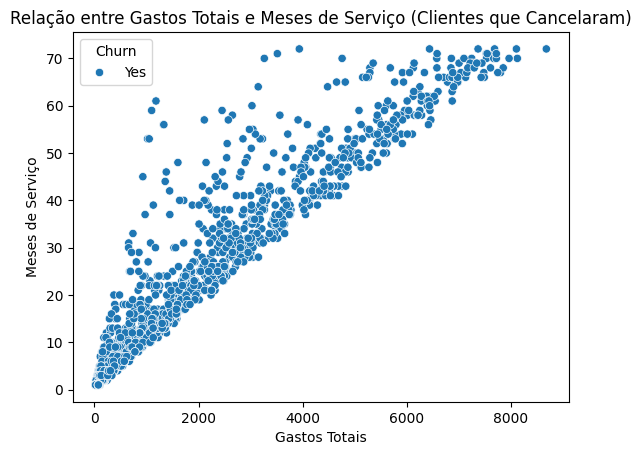

In [33]:
sns.scatterplot(x='TotalCharges', y='tenure', hue='Churn', data=df_churn_original_cols)
plt.title('Relação entre Gastos Totais e Meses de Serviço (Clientes que Cancelaram)')
plt.xlabel('Gastos Totais')
plt.ylabel('Meses de Serviço')
plt.show()

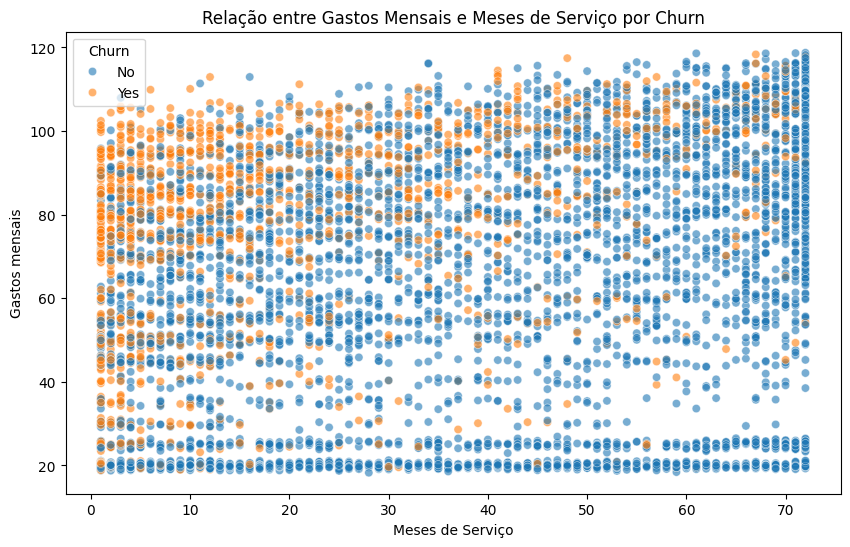

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, alpha=0.6)
plt.title('Relação entre Gastos Mensais e Meses de Serviço por Churn')
plt.xlabel('Meses de Serviço')
plt.ylabel('Gastos mensais')
plt.legend(title='Churn')
plt.show()

#### Insights finais e hipótese

1. **Relação entre Meses de Serviço e Gastos Mensais por Churn**

O gráfico mais revelador para nossos insights são o que compara Meses de Serviço com Gastos Mensais (o último gráfico gerado). Nele, observamos claramente:

+ *Concentração de Churn em Baixa Retenção em Meses*: Há uma densa aglomeração de clientes que cancelaram (Churn = Yes, pontos laranja) nos primeiros meses de serviço (baixo retenção em meses, por exemplo, de 0 a 10-15 meses). Isso indica que o período inicial do contrato é crítico para a retenção do cliente.
+ *Impacto de Gastos Mensais*: Dentro dessa faixa de baixo retenção em meses, notamos uma presença significativa de clientes que cancelaram com Gastos Mensais elevados (valores mais altos no eixo Y). Isso sugere que clientes que pagam mais por mês são mais propensos a cancelar logo no início, possivelmente porque a expectativa de valor não está sendo atendida rapidamente.
+ *Estabilidade em Alto Retenção em Meses*: À medida que os Meses de Serviço aumentam, a proporção de clientes que não cancelam (Churn = No, pontos azuis) se torna predominantemente maior, mesmo em planos com Gastos Mensais mais altos. Isso reforça a ideia de que, se um cliente permanece por um período mais longo, ele provavelmente encontrou valor no serviço, independentemente do custo mensal.

2. **Relação entre Gastos Totais e Meses de Serviço (Todos os Clientes e Apenas Churn)**

Os outros dois gráficos, que mostram a relação entre Gastos Totais e Meses de Serviço, com e sem a diferenciação por Churn, complementam essa análise:

+ *Acúmulo de Gastos Totais*: Naturalmente, os Gastos Totais aumentam com os Meses de Serviço. Clientes com Gastos Mensais mais altos acumulam Gastos Totais mais rapidamente.
+ *Churn em Baixa Retenção em Meses e Baixos Gastos Totais*: A forte concentração de clientes que cancelam em Meses de Serviço mais baixos, observada nesses gráficos, é consistente com o que vimos para Gastos Mensais. Muitos desses clientes cancelam antes que seus Gastos Totais se tornem muito elevados, o que faz sentido, pois se eles têm MonthlyCharges altos e cancelam cedo, seus TotalCharges não terão tempo de crescer muito.

**Conclusão**

Em resumo, a análise visual dos gráficos fornece forte suporte para a hipótese. Há um padrão claro de churn antecipado entre os clientes, e essa tendência é acentuada em planos com mensalidades mais altas.

Isso sugere que, para os clientes que optam por serviços mais caros, **a entrega de valor percebido é crucial nos primeiros meses.** Falhas nesse aspecto podem levar a uma rápida insatisfação e, consequentemente, ao cancelamento do serviço.

### Insight e Hipótese 2

#### Quem é a pessoa média que cancela?

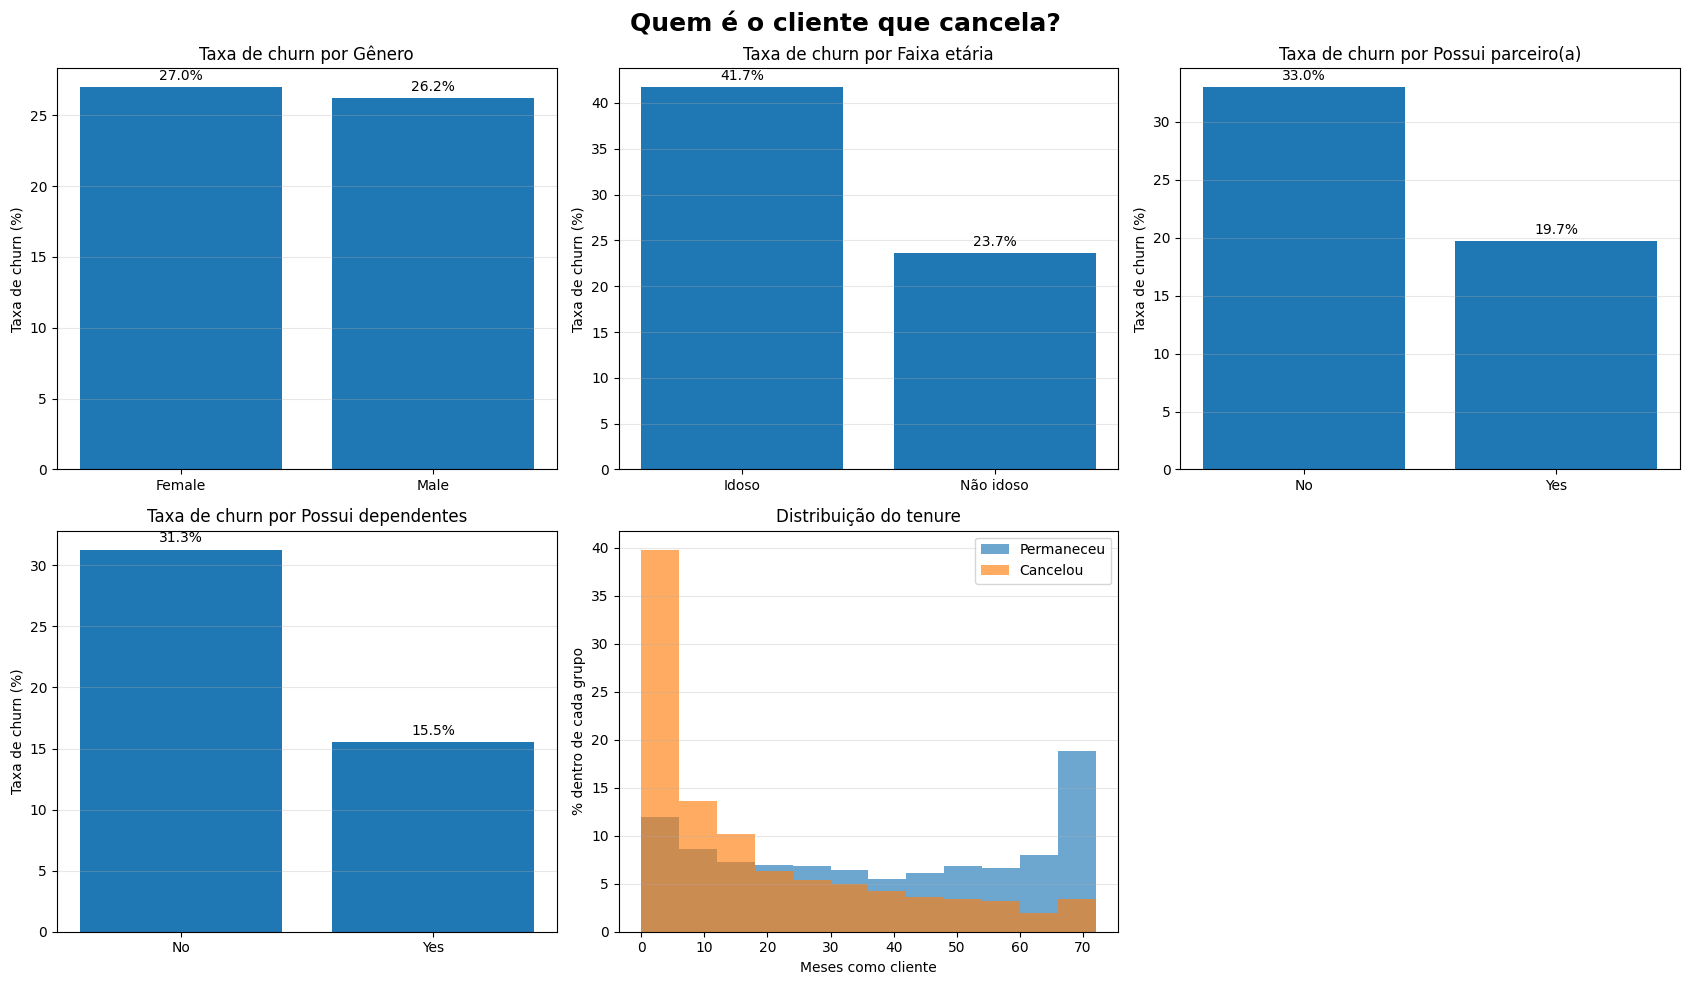

In [35]:
df['SeniorCitizenLabel'] = df['SeniorCitizen'].map({
    0: 'Não idoso',
    1: 'Idoso'
})

# Variáveis e títulos
variaveis = {
    'gender': 'Gênero',
    'SeniorCitizenLabel': 'Faixa etária',
    'Partner': 'Possui parceiro(a)',
    'Dependents': 'Possui dependentes'
}

# Criando o painel
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

# 1 a 4: Taxa de churn por característica
for i, (coluna, titulo) in enumerate(variaveis.items()):

    taxas = (
        df.groupby(coluna, observed=False)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
    )

    barras = axes[i].bar(
        taxas.index.astype(str),
        taxas.values
    )

    axes[i].set_title(f'Taxa de churn por {titulo}')
    axes[i].set_ylabel('Taxa de churn (%)')
    axes[i].bar_label(barras, fmt='%.1f%%', padding=3)
    axes[i].grid(axis='y', alpha=0.3)

# 5: Tenure dos clientes que cancelaram x permaneceram
bins = np.arange(0, 73, 6)

for churn, nome in [('No', 'Permaneceu'), ('Yes', 'Cancelou')]:
    dados = df.loc[df['Churn'] == churn, 'tenure']

    # Percentual dentro de cada grupo
    pesos = np.ones(len(dados)) * 100 / len(dados)

    axes[4].hist(
        dados,
        bins=bins,
        weights=pesos,
        alpha=0.65,
        label=nome
    )

axes[4].set_title('Distribuição do tenure')
axes[4].set_xlabel('Meses como cliente')
axes[4].set_ylabel('% dentro de cada grupo')
axes[4].legend()
axes[4].grid(axis='y', alpha=0.3)

# 6: Removendo espaço vazio
axes[5].axis('off')

fig.suptitle(

    'Quem é o cliente que cancela?',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#### Insights finais e hipótese

Clientes com menor tempo de relacionamento com a empresa e sem vínculos familiares (parceiro(a) ou dependentes) tendem a apresentar maiores taxas de cancelamento. Além disso, clientes idosos podem representar um grupo com maior propensão ao churn. O gênero, por sua vez, aparenta ter pouca relação com o cancelamento, considerando a pequena diferença observada entre homens e mulheres.

### Insight e Hipótese 3

#### Quais serviços mais usados pelos clientes de cancelados?

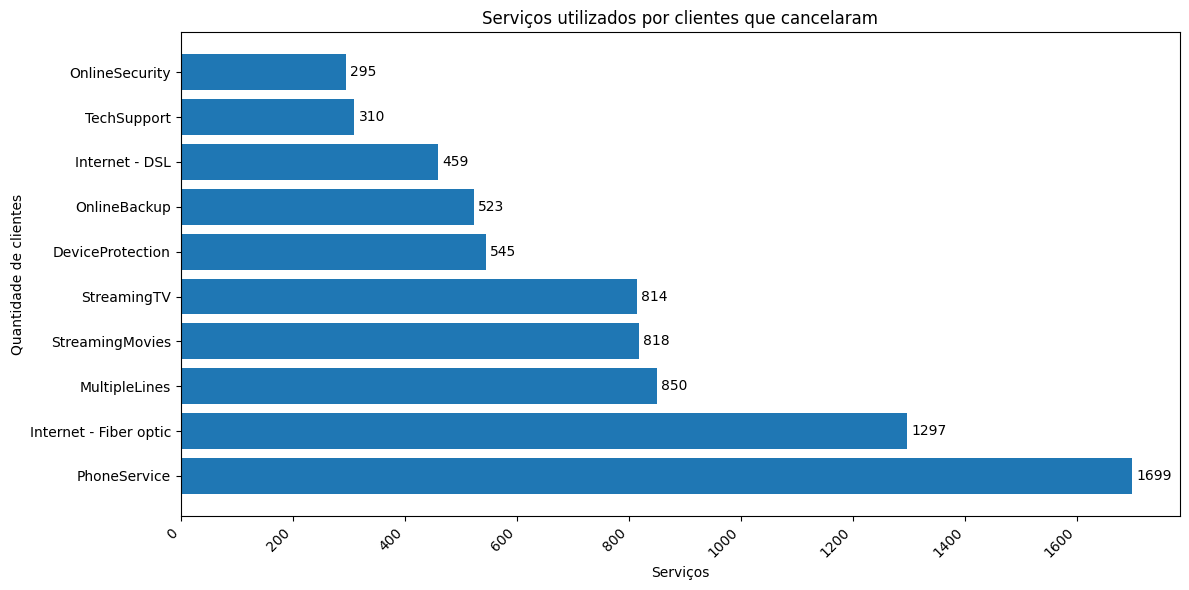

In [36]:
churn = df[df['Churn'] == 'Yes']

servicos = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

contagem = (churn[servicos] == 'Yes').sum()

internet = churn['InternetService'].value_counts()

contagem['Internet - DSL'] = internet.get('DSL', 0)
contagem['Internet - Fiber optic'] = internet.get('Fiber optic', 0)

contagem = contagem.sort_values(ascending=False)

plt.figure(figsize=(12, 6))

barras = plt.barh(
    contagem.index,
    contagem.values
)

plt.bar_label(barras, padding=3)

plt.title('Serviços utilizados por clientes que cancelaram')
plt.xlabel('Serviços')
plt.ylabel('Quantidade de clientes')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

#### Insights finais e hipótese 1

**O serviço telefônico**

Lendo o gráfico é perceptível que `PhoneService` é disparado o serviço mais presente entre todos os serviços dos cancelados — que impressionantemente é seguido pela fibra óptica —, mas qual o motivo disso?

Como podemos imaginar, no ano de 2026, quase não se usam serviços telefônicos.

- Telefone fixo? Isso ainda existe?
- Telefone celular? Se posso ligar pelo WhatsApp

**Fibra Óptica X DSL**

É surpreendente que a internet de Fibra Óptica tenha tido mais cancelamento que internet DSL, considerando a diferença de qualidade, mas isso levanta algumas hipóteses.

Hipóteses possíveis:

- O plano de fibra óptica poderia ter um preço maior.
- Os clientes de fibra podem ter um perfil de consumo diferente.

In [37]:
# Comparando a taxa de churn entre Fiber Optic e DSL

df_internet = df[df['InternetService'].isin(['DSL', 'Fiber optic'])].copy()

taxa_churn = pd.crosstab(
    df_internet['InternetService'],
    df_internet['Churn'],
    normalize='index'
) * 100

taxa_churn = taxa_churn[['Yes']].rename(columns={'Yes': 'Taxa de Churn (%)'})

display(taxa_churn.round(2))

Churn,Taxa de Churn (%)
InternetService,
DSL,19.00
Fiber optic,41.89


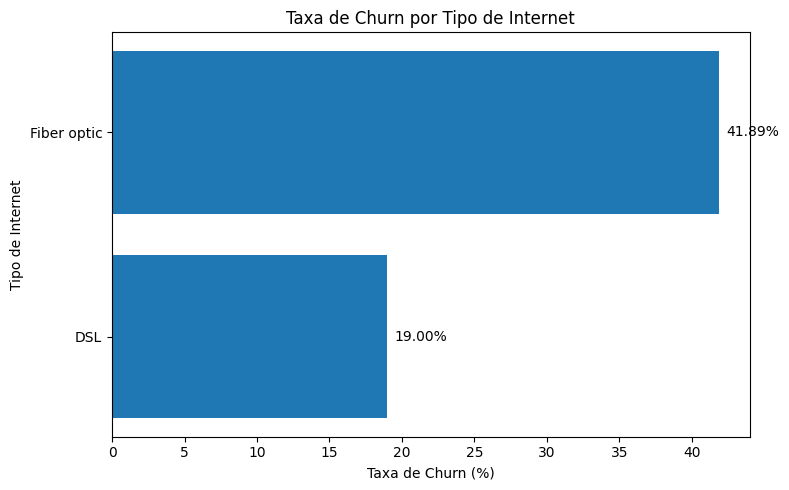

In [38]:
# Visualizar a taxa de cancelamento

taxas = df_internet.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

plt.figure(figsize=(8, 5))

barras = plt.barh(taxas.index, taxas.values)

plt.bar_label(
    barras,
    fmt='%.2f%%',
    padding=5
)

plt.title('Taxa de Churn por Tipo de Internet')
plt.xlabel('Taxa de Churn (%)')
plt.ylabel('Tipo de Internet')

plt.tight_layout()
plt.show()

In [39]:
# Investigar se o tipo de contrato influencia essa diferença

df_contratos = df[df['InternetService'].isin(['DSL', 'Fiber optic'])].copy()

churn_contrato = pd.crosstab(
    [df_contratos['InternetService'], df_contratos['Contract']],
    df_contratos['Churn'],
    normalize='index'
) * 100

churn_contrato = churn_contrato[['Yes']].rename(
    columns={'Yes': 'Taxa de Churn (%)'}
)

display(churn_contrato.round(2))

Churn                           Taxa de Churn (%)
InternetService Contract                         
DSL             Month-to-month              32.22
                One year                     9.30
                Two year                     1.93
Fiber optic     Month-to-month              54.61
                One year                    19.29
                Two year                     7.23

mean  median  count
InternetService Churn                      
DSL             No     60.20   59.75   1957
                Yes    49.08   49.25    459
Fiber optic     No     93.93   94.80   1799
                Yes    88.13   87.55   1297

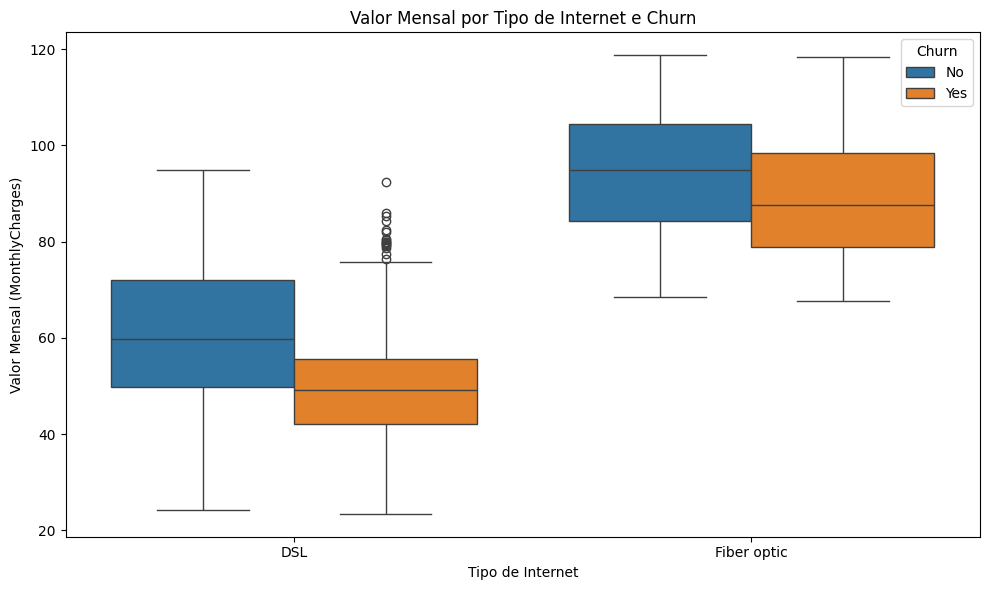

In [40]:
# Comparar o valor pago pelos clientes

df_precos = df[df['InternetService'].isin(['DSL', 'Fiber optic'])].copy()

precos = df_precos.groupby(
    ['InternetService', 'Churn']
)['MonthlyCharges'].agg(['mean', 'median', 'count'])

display(precos.round(2))

# Visualização dos valores mensais

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_precos,
    x='InternetService',
    y='MonthlyCharges',
    hue='Churn'
)

plt.title('Valor Mensal por Tipo de Internet e Churn')
plt.xlabel('Tipo de Internet')
plt.ylabel('Valor Mensal (MonthlyCharges)')

plt.tight_layout()
plt.show()

#### Hipótese 2

A análise mostrou que os clientes de Fiber Optic (fibra óptica) cancelam mais seus serviços (41,89%) do que os clientes de DSL (18,96%). Essa diferença continua mesmo quando separamos os clientes por tipo de contrato, mostrando que o contrato, sozinho, não explica essa diferença.

Também percebemos que, entre os clientes que cancelaram, a média da mensalidade era menor do que a dos clientes que permaneceram, tanto na fibra óptica quanto na DSL. Isso indica que o valor da mensalidade, por si só, não parece explicar os cancelamentos.

Concluímos que os clientes de fibra óptica apresentam uma taxa de cancelamento bem maior nessa base de dados. Por isso, vale investigar outros fatores, como a satisfação dos clientes, a qualidade percebida da internet, os serviços contratados e o perfil dos consumidores. Porém, esses dados mostram apenas uma relação entre os fatores, não sendo possível afirmar que um deles é a causa dos cancelamentos.
